<a href="https://colab.research.google.com/github/tsniang-cmkl/FTIR-Microplastics-Classification/blob/main/RF_GB_FTIR_Microplastics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌲 Gradient Boosting & Random Forest — Classification FTIR Microplastiques
### CMKL University | Stage 2026

**Objectif** : Établir des baselines ML classiques avant PatchTST  
**Modèles** : Random Forest + XGBoost + LightGBM  
**Données** : Même pipeline que le notebook PatchTST  

---
## Plan
1. Installation & Imports
2. Google Drive + Chargement des données
3. Prétraitement spectral
4. Extraction de features
5. Random Forest
6. Gradient Boosting (XGBoost + LightGBM)
7. Comparaison des modèles
8. Test sur les filtres à membrane
9. Récapitulatif vs PatchTST


## 1. Installation & Imports

In [ ]:
!pip install xgboost lightgbm scikit-learn seaborn -q
print('Installation OK ✓')

Installation OK ✓


In [ ]:
import os, glob, warnings, re, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Boosting
import xgboost as xgb
import lightgbm as lgb

# Reproductibilité
SEED = 42
np.random.seed(SEED)
print('Imports OK ✓')

Imports OK ✓


## 2. Google Drive & Chargement des données

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ⚠️ Adapter si besoin
DRIVE_ROOT = '/content/drive/MyDrive/Internship Datas/2026 - Complete FTIR Dataset'

PATHS = {
    '2023_base'    : os.path.join(DRIVE_ROOT, 'csv 2023 Dataset - 22 MP Types with 10 Clean and 60 Noisy'),
    'membrane'     : os.path.join(DRIVE_ROOT, 'csv 2023 and 2025 Membrane Filter'),
    '2025_ext'     : os.path.join(DRIVE_ROOT, 'csv 2025 Dataset 1 - Same 22 MP Types - Add 40 Spectra'),
    '2025_new'     : os.path.join(DRIVE_ROOT, 'csv 2025 Dataset 2 - New 9 MP Types - 50 Clean and 100 Noisy'),
}

# Format CSV par dossier
FOLDER_CONFIG = {
    '2023_base' : {'sep': ',',  'skiprows': 1},
    'membrane'  : {'sep': ',',  'skiprows': 1},
    '2025_ext'  : {'sep': ',',  'skiprows': 1},
    '2025_new'  : {'sep': ',',  'skiprows': 1},
}

for name, path in PATHS.items():
    n = len(glob.glob(os.path.join(path, '**/*.csv'), recursive=True))
    print(f'  {name:12s} | {"✓" if os.path.exists(path) else "✗"} | {n} CSV')

  2023_base    | ✓ | 65 CSV
  membrane     | ✓ | 6 CSV
  2025_ext     | ✓ | 23 CSV
  2025_new     | ✓ | 17 CSV


In [ ]:
# ── Extraction du label depuis le nom de fichier ──────────────────────────

EXCLUDE_FILES = {'ref.csv', 'reference.csv', 'background.csv', 'bg.csv'}
LABEL_BLACKLIST = {'test', 'internship', 'data',
                   'datas', 'spectra', 'spectre', '2023', '2025'}

def extract_label(filepath):
    name = Path(filepath).stem.lower()

    # 1. Le dictionnaire des mots à pulvériser (ajout de sd, rm, jan, particle, x...)
    mots_a_supprimer = r'\b(clean|noisy|add|new|spectrums?|spectra|sd|rm|jan|particle|x)\b'
    name = re.sub(mots_a_supprimer, '', name)

    # 2. On efface tous les chiffres
    name = re.sub(r'\d+', '', name)

    # 3. On remplace les tirets/underscores par des espaces
    name = name.replace('_', ' ').replace('-', ' ')

    # 4. On supprime les espaces multiples restants
    name = ' '.join(name.split())

    return name.upper()

def read_spectrum(filepath, sep=',', skiprows=0):
    """
    Lit un CSV multi-spectres de manière ultra-robuste.
    Lit l'en-tête (même ignoré) pour repérer et détruire l'AIR et le Background.
    """
    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()

        start_idx = 0
        for i, line in enumerate(lines):
            parts = line.strip().split(sep)
            if len(parts) >= 2:
                try:
                    float(parts[0].replace(',', '.'))
                    start_idx = i # C'est ici que commencent les chiffres
                    break
                except ValueError:
                    continue

        valid_data_str = "".join(lines[start_idx:])

        try:
            df_raw = pd.read_csv(io.StringIO(valid_data_str), sep=sep, header=None, decimal=',')
        except:
            df_raw = pd.read_csv(io.StringIO(valid_data_str), sep=sep, header=None, decimal='.')

        # 🔴 NOUVEAU RADAR : On extrait la ligne de texte juste au-dessus des chiffres
        if start_idx > 0:
            headers = lines[start_idx - 1].strip().split(sep)
        else:
            headers = []

        cols_to_keep = []
        for col_idx, col_name in enumerate(df_raw.columns):
            # On vérifie le nom dans l'en-tête
            header_str = str(headers[col_idx]).upper() if col_idx < len(headers) else ""
            # On vérifie aussi la première case (au cas où)
            first_val = str(df_raw[col_name].iloc[0]).upper()

            # 🧨 Si on détecte de l'air ou du bruit, on supprime la colonne !
            if "AIR" in header_str or "BACKGROUND" in header_str or "BG" in header_str:
                continue
            if "AIR" in first_val or "BACKGROUND" in first_val or "BG" in first_val:
                continue

            cols_to_keep.append(col_name)

        # On ne garde que les vrais plastiques
        df = df_raw[cols_to_keep].copy()

        # On convertit en nombres
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.dropna(subset=[df.columns[0]])

        wn = df.iloc[:, 0].values.astype(float)

        order = np.argsort(wn)
        wn    = wn[order]

        spectra = []
        for col_idx in range(1, df.shape[1]):
            ab = df.iloc[order, col_idx].values.astype(float)

            if np.isnan(ab).all() or ab.std() < 1e-10:
                continue

            nans = np.isnan(ab)
            if nans.any():
                ab[nans] = np.interp(
                    np.where(nans)[0],
                    np.where(~nans)[0],
                    ab[~nans]
                )

            spectra.append(ab.astype(np.float32))

        if len(spectra) == 0:
            return None

        return wn, spectra

    except Exception as e:
        print(f'  ✗ {os.path.basename(filepath)} : {e}')
        return None

def load_all(folder_paths, folder_config):
    records     = []
    mem_records = []

    for name, folder in folder_paths.items():
        if not os.path.exists(folder):
            continue

        cfg   = folder_config.get(name, {'sep': ',', 'skiprows': 0})
        files = glob.glob(os.path.join(folder, '**/*.csv'), recursive=True)

        n_files, n_spectra = 0, 0

        for fp in files:
            if Path(fp).name.lower() in EXCLUDE_FILES:
                continue

            result = read_spectrum(fp, sep=cfg['sep'], skiprows=cfg['skiprows'])
            if result is None:
                continue

            wn, spectra_list = result
            label = extract_label(fp)

            if any(b in label.lower() for b in LABEL_BLACKLIST):
                continue

            for sp in spectra_list:
                rec = {
                    'filepath' : fp,
                    'label'    : label,
                    'source'   : name,
                    'wn'       : wn,
                    'spectrum' : sp,
                    'n_points' : len(sp),
                }
                if name == 'membrane':
                    mem_records.append(rec)
                else:
                    records.append(rec)

            n_files   += 1
            n_spectra += len(spectra_list)

        print(f'  {name:12s} | {n_files} fichiers | {n_spectra} spectres')

    return pd.DataFrame(records), pd.DataFrame(mem_records)

# Lancement de l'extraction
print("Lecture des fichiers en cours, veuillez patienter...\n")
df_train_raw, df_membrane = load_all(PATHS, FOLDER_CONFIG)
print(f'\n✓ Dataset principal : {len(df_train_raw)} spectres | {df_train_raw["label"].nunique()} classes')
print(f'✓ Filtres membrane  : {len(df_membrane)} spectres')

Lecture des fichiers en cours, veuillez patienter...

  2023_base    | 65 fichiers | 1528 spectres
  membrane     | 6 fichiers | 180 spectres
  2025_ext     | 23 fichiers | 921 spectres
  2025_new     | 17 fichiers | 1145 spectres

✓ Dataset principal : 3594 spectres | 104 classes
✓ Filtres membrane  : 180 spectres


In [ ]:
import glob
import os

print("🔍 ENQUÊTE SUR LES DOSSIERS MEMBRANES 🔍\n")
membrane_files = glob.glob(os.path.join(PATHS['membrane'], '**/*.csv'), recursive=True)

total = 0
for fp in membrane_files:
    result = read_spectrum(fp)
    if result:
        nb_spectres = len(result[1])
        total += nb_spectres
        print(f"📄 {os.path.basename(fp)} -> {nb_spectres} spectres trouvés")

print(f"\nTOTAL : {total} spectres")

🔍 ENQUÊTE SUR LES DOSSIERS MEMBRANES 🔍

📄 Membrane filter_SD.csv -> 30 spectres trouvés
📄 Filter membrane Cellulose Nitrate_30 spectrums.csv -> 30 spectres trouvés
📄 Filter membrane PTFE_30 spectrums.csv -> 30 spectres trouvés
📄 Filter membrane Glass Fiber_30 spectrums.csv -> 30 spectres trouvés
📄 Filter membrane Cellulose Acetate_30 spectrums.csv -> 30 spectres trouvés
📄 Filter membrane Nylon_30 spectrums.csv -> 30 spectres trouvés

TOTAL : 180 spectres



=== 2023_base ===
Fichier   : PLA_RM_10 spectrums.csv
Wavenumbers : 650 – 4000 cm⁻¹ (6950 points)
Spectres  : 10 colonnes lues


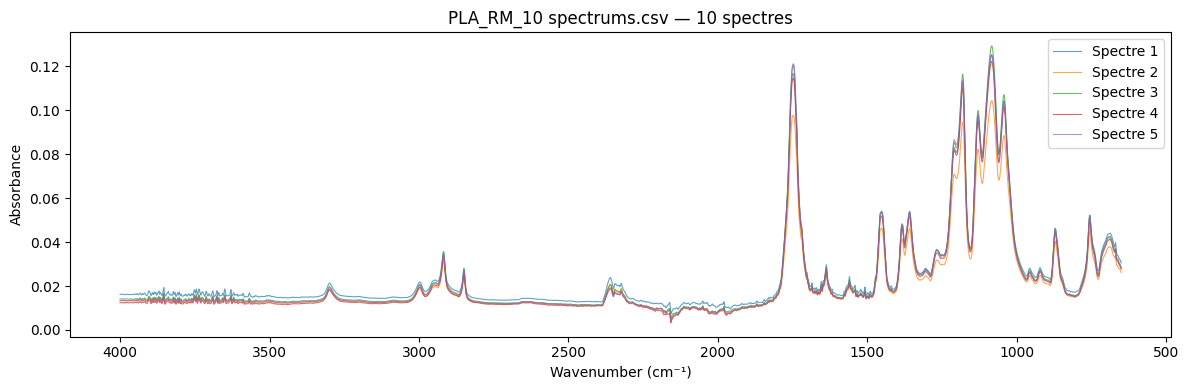


=== membrane ===
Fichier   : Membrane filter_SD.csv
Wavenumbers : 525 – 4000 cm⁻¹ (14416 points)
Spectres  : 30 colonnes lues


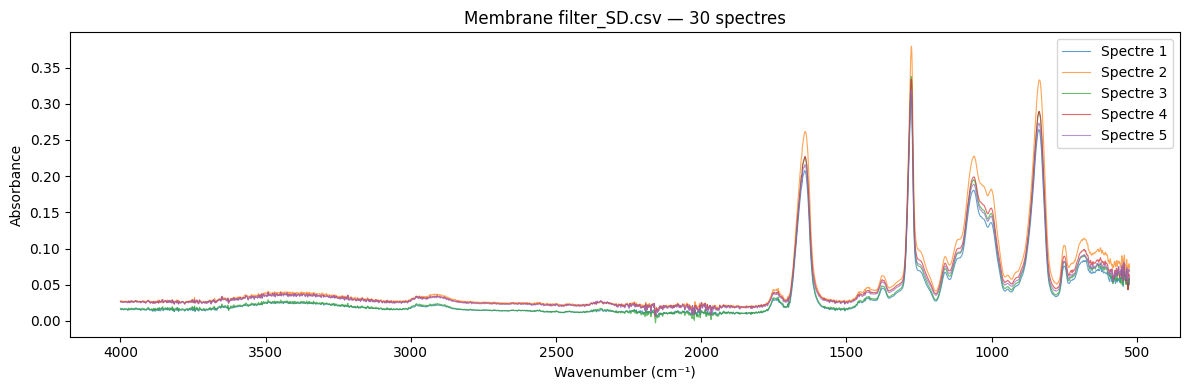


=== 2025_ext ===
Fichier   : LDPE-add_40 spectrums.csv
Wavenumbers : 550 – 4000 cm⁻¹ (7157 points)
Spectres  : 40 colonnes lues


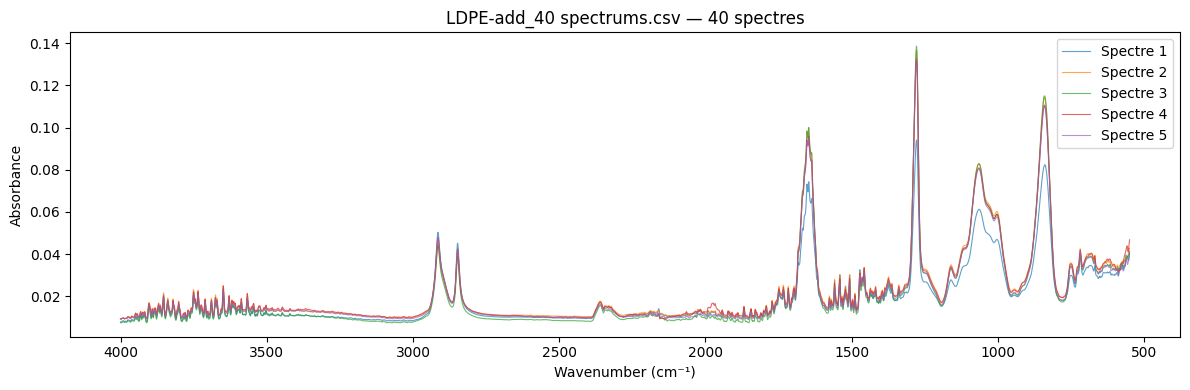


=== 2025_new ===
Fichier   : PHB-noisy_60 spectrums.csv
Wavenumbers : 550 – 4000 cm⁻¹ (7157 points)
Spectres  : 60 colonnes lues


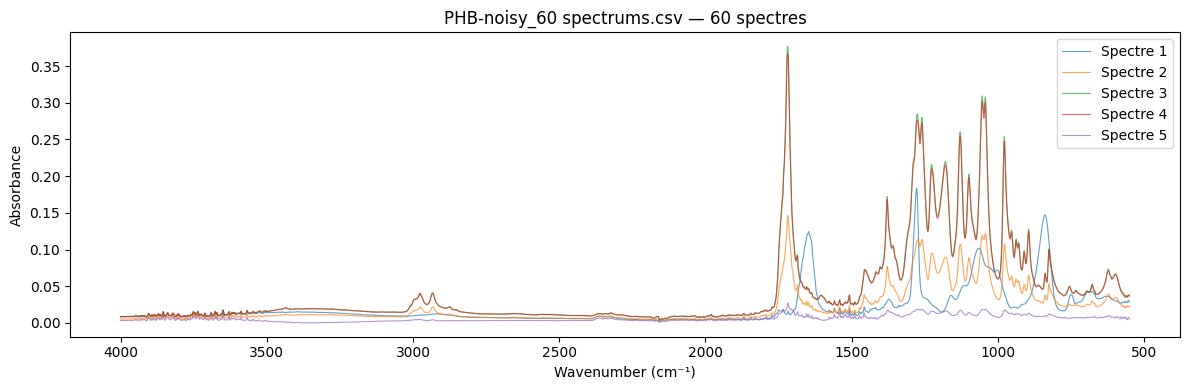

In [ ]:
def inspect_multispectrum(filepath, sep=',', skiprows=0):
    """Affiche ce que contient un fichier multi-spectres."""
    result = read_spectrum(filepath, sep=sep, skiprows=skiprows)
    if result is None:
        print('Lecture échouée')
        return

    wn, spectra = result
    print(f'Fichier   : {os.path.basename(filepath)}')
    print(f'Wavenumbers : {wn.min():.0f} – {wn.max():.0f} cm⁻¹ ({len(wn)} points)')
    print(f'Spectres  : {len(spectra)} colonnes lues')

    # Visualiser les 5 premiers
    plt.figure(figsize=(12, 4))
    for i, sp in enumerate(spectra[:5]):
        plt.plot(wn, sp, alpha=0.7, linewidth=0.8, label=f'Spectre {i+1}')
    plt.xlabel('Wavenumber (cm⁻¹)')
    plt.ylabel('Absorbance')
    plt.title(f'{os.path.basename(filepath)} — {len(spectra)} spectres')
    plt.gca().invert_xaxis()
    plt.legend()
    plt.tight_layout()
    plt.show()

# Test sur un fichier de chaque dossier
for name, folder in PATHS.items():
    files = glob.glob(os.path.join(folder, '**/*.csv'), recursive=True)
    if files:
        cfg = FOLDER_CONFIG[name]
        print(f'\n=== {name} ===')
        inspect_multispectrum(files[0], sep=cfg['sep'], skiprows=cfg['skiprows'])

In [ ]:
# Regarder les 5 premières lignes brutes du premier fichier 2023_base
files_2023 = glob.glob(os.path.join(PATHS['2023_base'], '**/*.csv'), recursive=True)
print(f'{len(files_2023)} fichiers trouvés')
print(f'Premier : {files_2023[0]}')
print('\n--- Contenu brut ---')
with open(files_2023[0], 'r', encoding='utf-8', errors='replace') as f:
    for i, line in enumerate(f):
        if i >= 5: break
        print(repr(line.rstrip()))

65 fichiers trouvés
Premier : /content/drive/MyDrive/Internship Datas/2026 - Complete FTIR Dataset/csv 2023 Dataset - 22 MP Types with 10 Clean and 60 Noisy/1. Clean Spectra - 10 Each/PLA_RM_10 spectrums.csv

--- Contenu brut ---
'Wavenumber_cm-1,PLA_RM_10,PLA_RM_9,PLA_RM_8,PLA_RM_7,PLA_RM_6,PLA_RM_5,PLA_RM_4,PLA_RM_3,PLA_RM_2,PLA_RM_1,AIR'
'4000.122070,0.01621484,0.01331012,0.01405837,0.01238396,0.01335614,0.01259928,0.01163383,0.01055324,0.01092939,0.00960357,-0.00052568'
'3999.639954,0.01622034,0.01329707,0.01405166,0.01238921,0.01336017,0.01259532,0.01162913,0.01054849,0.01093096,0.00960774,-0.00052072'
'3999.157837,0.01622650,0.01328764,0.01404889,0.01239914,0.01336356,0.01259628,0.01162569,0.01054523,0.01093204,0.00961533,-0.00051503'
'3998.675720,0.01623245,0.01328289,0.01405104,0.01241195,0.01336540,0.01260170,0.01162260,0.01054340,0.01093150,0.00962451,-0.00050884'


## 3. Prétraitement spectral
Interpolation sur la grille commune du spectromètre.

Interpolation...
✓ 3594 spectres à 1727 points (650–4000 cm⁻¹)

=== Classes ===
label
PVDF NOISY                    100
EVA NOISY                     100
PF THERMOSET NOISY            100
ABS NOISY                     100
PHB NOISY                     100
CHITOSAN NOISY                100
PF THERMOPLASTIC NOISY        100
NYLON PARTICLE SD SPECTUMS     60
PU SD                          50
PS SD                          50
PTEE SD                        50
PLA SD                         50
ENR SD                         50
PEI SD                         50
PP SD                          50
ABS CLEAN                      50
CHITOSAN CLEAN                 50
PF THERMOPLASTIC CLEAN         50
PVDF CLEAN                     50
PET SD                         50
PVC SD                         50
PMMA SD                        50
POM SD                         50
PVA SD                         50
CELLULOSE SD                   50
PC SD                          50
PBS SD                        

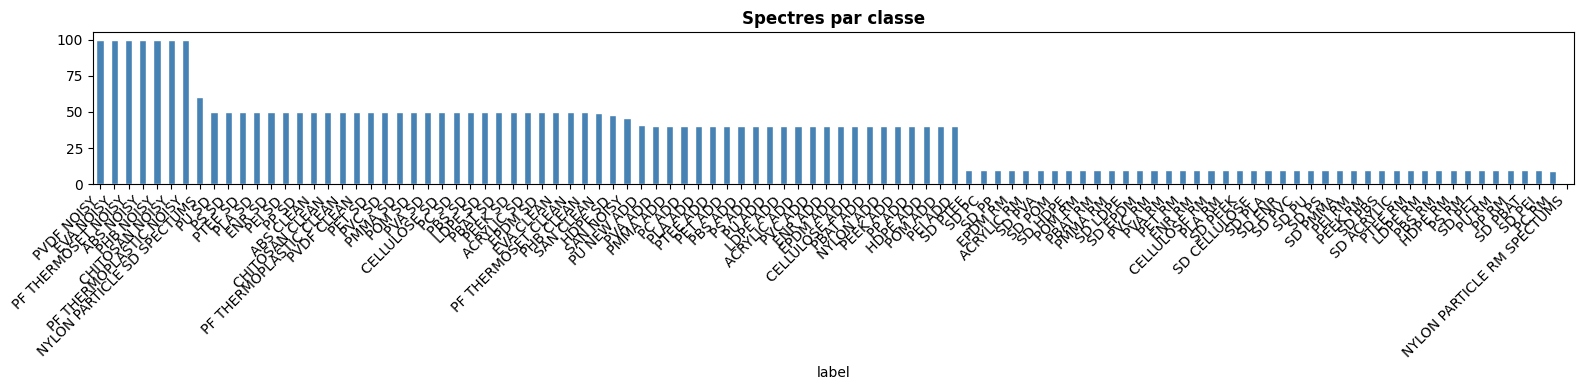

In [ ]:
WN_MIN = 650
WN_MAX = 4000
L      = 1727
WN_GRID = np.linspace(WN_MIN, WN_MAX, L)

def interp_spectrum(wn, ab):
    sp = np.interp(WN_GRID, wn, ab)
    return np.nan_to_num(sp, 0.0).astype(np.float32)

def instance_norm(sp):
    """Normalisation par spectre (comme PatchTST)"""
    mu, sigma = sp.mean(), sp.std() + 1e-8
    return (sp - mu) / sigma

print('Interpolation...')
df_train_raw['spectrum_interp'] = df_train_raw.apply(
    lambda r: interp_spectrum(r['wn'], r['spectrum']), axis=1)

df_membrane['spectrum_interp'] = df_membrane.apply(
    lambda r: interp_spectrum(r['wn'], r['spectrum']), axis=1)

print(f'✓ {len(df_train_raw)} spectres à {L} points ({WN_MIN}–{WN_MAX} cm⁻¹)')

# ── Distribution des classes ───────────────────────────────────────────────
counts = df_train_raw['label'].value_counts()
print(f'\n=== Classes ===')
print(counts.to_string())

plt.figure(figsize=(16, 4))
counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Spectres par classe', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import re

print("🧹 Nettoyage des labels en cours...")

def super_cleaner(label):
    # 1. Tout mettre en majuscules
    lbl = str(label).upper()

    # 2. La liste de tous les mots parasites vus dans ton terminal
    parasites = [
        r'\bNOISY\b', r'\bCLEAN\b', r'\bADD\b', r'\bNEW\b',
        r'\bSD\b', r'\bRM\b', r'\bJAN\b', r'\bSPECTUMS\b',
        r'\bSPECTRA\b', r'\bSPECTRUMS\b', r'\bPARTICLE\b', r'\bX\b'
    ]

    for p in parasites:
        lbl = re.sub(p, '', lbl)

    # 3. Enlever les chiffres restants, tirets et underscores
    lbl = re.sub(r'\d+', '', lbl)
    lbl = lbl.replace('_', ' ').replace('-', ' ')

    # 4. Nettoyer les espaces en trop
    return ' '.join(lbl.split())

# On applique la correction directement sur ton dataset chargé
df_train_raw['label'] = df_train_raw['label'].apply(super_cleaner)

# On revérifie la distribution !
counts_clean = df_train_raw['label'].value_counts()
print(f'\n=== Nouvelles Classes Propres ({len(counts_clean)} plastiques) ===')
print(counts_clean.to_string())

🧹 Nettoyage des labels en cours...

=== Nouvelles Classes Propres (30 plastiques) ===
label
PU                  151
CHITOSAN            150
PF THERMOPLASTIC    150
PF THERMOSET        150
ABS                 150
EVA                 150
PHB                 150
PVDF                150
PLA                 110
CELLULOSE           110
ENR                 110
PET                 110
PVA                 110
PVC                 110
LDPE                110
PP                  110
PS                  110
POM                 110
PBAT                110
PMMA                110
EPDM                110
ACRYLIC             110
PEI                 110
PEEK                110
PTEE                110
PBS                 110
PC                  109
HDPE                108
NYLON               101
SAN                  95


## 4. Extraction de features

RF et GB ne peuvent pas traiter des séquences brutes de 1727 points efficacement.  
On extrait 3 types de features complémentaires :

| Type | Dimension | Ce que ça capture |
|------|-----------|-------------------|
| **Spectre brut normalisé** | 1727 | Toute l'information, mais haute dim. |
| **PCA** | 50 | Composantes principales du spectre |
| **Features spectrales** | ~30 | Bandes chimiques clés, stats globales |

On testera les 3 combinaisons.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# FEATURES SPECTRALES FTIR
# Bandes d'absorption caractéristiques des polymères / microplastiques
# ══════════════════════════════════════════════════════════════════════════

# Chaque bande = (nom, centre_cm-1, demi-largeur)
FTIR_BANDS = [
    # Groupements C-H
    ('CH3_asym',   2962, 15),  # CH3 asymétrique
    ('CH2_asym',   2926, 15),  # CH2 asymétrique → PE, PP
    ('CH2_sym',    2853, 15),  # CH2 symétrique  → PE, PP
    ('CH_bend',    1460, 15),  # déformation C-H
    ('CH3_rock',   1375, 12),  # balancement CH3 → PP
    # Groupements C=O
    ('CO_ester',   1735, 20),  # ester → PET, PLA, PBAT
    ('CO_carbonat',1775, 20),  # carbonate → PC
    ('CO_amide',   1650, 20),  # amide I → Nylon
    ('CO_acid',    1712, 15),  # acide carboxylique
    # C-O
    ('CO_stretch1', 1260, 20), # C-O-C ester → PET
    ('CO_stretch2', 1100, 25), # C-O éther → cellulose, PEO
    ('CO_stretch3', 1020, 20), # C-O alcool
    # Groupements aromatiques
    ('arom_ring',   1600, 15), # C=C aromatique → PS, PET
    ('arom_CH',     3030, 15), # C-H aromatique → PS
    ('arom_oop',     700, 20), # out-of-plane → PS
    # O-H / N-H
    ('OH_broad',    3330, 80), # O-H large → cellulose, chitosan, PVA
    ('NH_stretch',  3300, 30), # N-H → nylon, PU
    # C-Cl / C-F
    ('CCl_stretch',  690, 20), # C-Cl → PVC
    ('CF_stretch',  1210, 30), # C-F  → PTFE
    # C=C
    ('CC_alkene',   1640, 15), # C=C → NR, ENR
    ('CC_diene',     970, 15), # trans C=C → polyisoprène
]

def get_band_intensity(spectrum, wn_grid, center, half_width):
    """Intensité moyenne dans une fenêtre spectrale."""
    mask = (wn_grid >= center - half_width) & (wn_grid <= center + half_width)
    if mask.sum() == 0:
        return 0.0
    return float(spectrum[mask].mean())

def get_band_peak(spectrum, wn_grid, center, half_width):
    """Intensité maximale dans une fenêtre spectrale."""
    mask = (wn_grid >= center - half_width) & (wn_grid <= center + half_width)
    if mask.sum() == 0:
        return 0.0
    return float(spectrum[mask].max())

def extract_spectral_features(spectrum, wn_grid=WN_GRID):
    """
    Extrait ~70 features spectrales d'un spectre FTIR :
      - Intensité moyenne de chaque bande FTIR clé
      - Pic maximum de chaque bande
      - Ratios de bandes (diagnostiques de polymères)
      - Features statistiques globales
    """
    sp = instance_norm(spectrum)  # normaliser avant extraction
    features = {}

    # ── Intensités des bandes ──────────────────────────────────
    for name, center, hw in FTIR_BANDS:
        features[f'mean_{name}']  = get_band_intensity(sp, wn_grid, center, hw)
        features[f'peak_{name}']  = get_band_peak(sp, wn_grid, center, hw)

    # ── Ratios diagnostiques ───────────────────────────────────
    eps = 1e-8
    # Ratio CH2/CH3 : distingue PE (beaucoup CH2) de PP (CH3 présent)
    features['ratio_CH2_CH3']    = features['mean_CH2_asym'] / (features['mean_CH3_asym'] + eps)
    # Ratio C=O / CH2 : distingue les polyesters des polyoléfines
    features['ratio_CO_CH2']     = features['mean_CO_ester'] / (features['mean_CH2_asym'] + eps)
    # Ratio OH / CH2 : distingue cellulose/PVA des plastiques
    features['ratio_OH_CH2']     = features['mean_OH_broad'] / (features['mean_CH2_asym'] + eps)
    # Ratio C-Cl / CH2 : détecte PVC
    features['ratio_CCl_CH2']    = features['mean_CCl_stretch'] / (features['mean_CH2_asym'] + eps)
    # Ratio aromatique / aliphatique : PS, PET vs PE, PP
    features['ratio_arom_aliph']  = features['mean_arom_ring'] / (features['mean_CH2_asym'] + eps)
    # Ratio C-F / CH2 : détecte PTFE
    features['ratio_CF_CH2']     = features['mean_CF_stretch'] / (features['mean_CH2_asym'] + eps)

    # ── Stats globales ─────────────────────────────────────────
    features['global_mean']   = float(sp.mean())
    features['global_std']    = float(sp.std())
    features['global_max']    = float(sp.max())
    features['global_min']    = float(sp.min())
    features['global_skew']   = float(pd.Series(sp).skew())
    features['global_kurt']   = float(pd.Series(sp).kurt())

    # ── Régions spectrales larges ──────────────────────────────
    for label, lo, hi in [('fingerprint', 650, 1500),
                           ('functional',  1500, 2000),
                           ('CH_region',   2700, 3000),
                           ('OH_region',   3000, 3700)]:
        mask = (wn_grid >= lo) & (wn_grid <= hi)
        if mask.sum() > 0:
            features[f'region_{label}_mean'] = float(sp[mask].mean())
            features[f'region_{label}_max']  = float(sp[mask].max())
            features[f'region_{label}_std']  = float(sp[mask].std())

    return features


# Test sur un spectre
test_feat = extract_spectral_features(df_train_raw['spectrum_interp'].iloc[0])
print(f'Nombre de features spectrales : {len(test_feat)}')
print('Exemples :', list(test_feat.keys())[:8], '...')

Nombre de features spectrales : 66
Exemples : ['mean_CH3_asym', 'peak_CH3_asym', 'mean_CH2_asym', 'peak_CH2_asym', 'mean_CH2_sym', 'peak_CH2_sym', 'mean_CH_bend', 'peak_CH_bend'] ...


In [ ]:
# ── Construire les matrices de features ───────────────────────────────────
print('Extraction des features...')

# 1. Spectre brut normalisé
X_raw = np.vstack([
    instance_norm(sp) for sp in df_train_raw['spectrum_interp']
])

# 2. Features spectrales
feat_list = [extract_spectral_features(sp) for sp in df_train_raw['spectrum_interp']]
X_feat = pd.DataFrame(feat_list).values.astype(np.float32)

# 3. PCA sur le spectre brut (50 composantes)
pca = PCA(n_components=50, random_state=SEED)
X_pca = pca.fit_transform(X_raw)
print(f'  Variance expliquée PCA 50 comp. : {pca.explained_variance_ratio_.sum():.1%}')

# 4. Combinaison features spectrales + PCA
X_combined = np.hstack([X_feat, X_pca])

print(f'\nDimensions des matrices de features :')
print(f'  X_raw      : {X_raw.shape}      (spectre brut)')
print(f'  X_feat     : {X_feat.shape}     (features spectrales)')
print(f'  X_pca      : {X_pca.shape}      (PCA 50 comp.)')
print(f'  X_combined : {X_combined.shape}  (feat + PCA)')

Extraction des features...
  Variance expliquée PCA 50 comp. : 99.9%

Dimensions des matrices de features :
  X_raw      : (3594, 1727)      (spectre brut)
  X_feat     : (3594, 66)     (features spectrales)
  X_pca      : (3594, 50)      (PCA 50 comp.)
  X_combined : (3594, 116)  (feat + PCA)


In [ ]:
# ── Encodage des labels & split ───────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df_train_raw['label'])
N_CLASSES = len(le.classes_)
print(f'Classes : {N_CLASSES}')

# Gérer les singletons (1 seul spectre par classe → stratify plante)
counts_y = Counter(y)
singleton_mask = np.array([counts_y[yi] == 1 for yi in y])
multi_mask     = ~singleton_mask

X_multi, y_multi = X_combined[multi_mask], y[multi_mask]
X_single, y_single = X_combined[singleton_mask], y[singleton_mask]

X_tr_base, X_val, y_tr_base, y_val = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=SEED, stratify=y_multi)

# Forcer les singletons dans le train
X_train = np.vstack([X_tr_base, X_single])
y_train = np.concatenate([y_tr_base, y_single])

# Même split pour les autres matrices
def apply_split(X):
    Xm, Xs = X[multi_mask], X[singleton_mask]
    Xtr, Xv = train_test_split(Xm, test_size=0.2, random_state=SEED,
                                stratify=y_multi)
    return np.vstack([Xtr, Xs]), Xv

X_raw_train,  X_raw_val  = apply_split(X_raw)
X_feat_train, X_feat_val = apply_split(X_feat)
X_pca_train,  X_pca_val  = apply_split(X_pca)

print(f'Train : {len(X_train)} | Val : {len(X_val)}')

# Features membrane
feat_mem    = [extract_spectral_features(sp) for sp in df_membrane['spectrum_interp']]
X_mem_feat  = pd.DataFrame(feat_mem).values.astype(np.float32)
X_mem_raw   = np.vstack([instance_norm(sp) for sp in df_membrane['spectrum_interp']])
X_mem_pca   = pca.transform(X_mem_raw)
X_mem_comb  = np.hstack([X_mem_feat, X_mem_pca])
print(f'Membrane test : {len(X_mem_comb)} spectres')

Classes : 30
Train : 2875 | Val : 719
Membrane test : 180 spectres


## 5. Random Forest

On entraîne et compare RF sur les 4 types de features.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ── Hyperparamètres RF ────────────────────────────────────────────────────
RF_PARAMS = dict(
    n_estimators   = 500,
    max_depth      = None,   # arbres profonds (RF gère l'overfitting via bagging)
    min_samples_leaf = 1,
    max_features   = 'sqrt', # sqrt(n_features) par split
    class_weight   = 'balanced',
    n_jobs         = -1,
    random_state   = SEED,
)

# ── Entraînement sur les 4 feature sets ──────────────────────────────────
rf_results = {}

feature_sets = {
    'Spectre brut (1727d)' : (X_raw_train,  X_raw_val),
    'PCA 50 comp.'        : (X_pca_train,  X_pca_val),
    'Features spectrales' : (X_feat_train, X_feat_val),
    'Combined (feat+PCA)' : (X_train,      X_val),
}

print(f'=== Random Forest ({RF_PARAMS["n_estimators"]} arbres) ===')
print(f'{"Feature set":25s} | {"Val Acc":>8} | {"Val F1":>8}')
print('-' * 50)

for name, (Xtr, Xv) in feature_sets.items():
    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(Xtr, y_train[:len(Xtr)])
    preds = rf.predict(Xv)
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, average='macro', zero_division=0)
    rf_results[name] = {'model': rf, 'acc': acc, 'f1': f1, 'preds': preds}
    print(f'{name:25s} | {acc:8.2%} | {f1:8.3f}')

best_rf_name = max(rf_results, key=lambda k: rf_results[k]['acc'])
best_rf      = rf_results[best_rf_name]['model']
print(f'\n→ Meilleur RF : {best_rf_name} ({rf_results[best_rf_name]["acc"]:.2%})')

=== Random Forest (500 arbres) ===
Feature set               |  Val Acc |   Val F1
--------------------------------------------------
Spectre brut (1727d)      |   98.47% |    0.984
PCA 50 comp.              |   98.61% |    0.985
Features spectrales       |   96.80% |    0.966
Combined (feat+PCA)       |   98.75% |    0.986

→ Meilleur RF : Combined (feat+PCA) (98.75%)


In [ ]:
# ── Rapport détaillé du meilleur RF ──────────────────────────────────────
best_preds_rf = rf_results[best_rf_name]['preds']
print(f'=== Classification Report — RF ({best_rf_name}) ===')
print(classification_report(y_val, best_preds_rf,
                             target_names=le.classes_, zero_division=0))

=== Classification Report — RF (Combined (feat+PCA)) ===
                  precision    recall  f1-score   support

             ABS       1.00      1.00      1.00        30
         ACRYLIC       0.95      0.91      0.93        22
       CELLULOSE       1.00      1.00      1.00        22
        CHITOSAN       1.00      1.00      1.00        30
             ENR       1.00      1.00      1.00        22
            EPDM       1.00      1.00      1.00        22
             EVA       1.00      1.00      1.00        30
            HDPE       1.00      1.00      1.00        22
            LDPE       1.00      0.95      0.98        22
           NYLON       0.95      1.00      0.98        20
            PBAT       1.00      1.00      1.00        22
             PBS       0.96      1.00      0.98        22
              PC       1.00      1.00      1.00        22
            PEEK       1.00      0.95      0.98        22
             PEI       1.00      1.00      1.00        22
             P

In [ ]:
# ── Importance des features (RF) ──────────────────────────────────────────
if best_rf_name == 'Features spectrales':
    feat_names   = list(pd.DataFrame([extract_spectral_features(
        df_train_raw['spectrum_interp'].iloc[0])]).columns)
    importances  = best_rf.feature_importances_
    sorted_idx   = np.argsort(importances)[::-1][:20]

    plt.figure(figsize=(12, 5))
    plt.bar(range(20), importances[sorted_idx], color='steelblue', edgecolor='white')
    plt.xticks(range(20), [feat_names[i] for i in sorted_idx], rotation=45, ha='right')
    plt.title('Top 20 features — Random Forest', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    # Pour le spectre brut ou PCA : importance par wavenumber
    importances = best_rf.feature_importances_
    if len(importances) == L:  # spectre brut
        plt.figure(figsize=(14, 4))
        plt.plot(WN_GRID, importances, color='steelblue', linewidth=0.8)
        plt.fill_between(WN_GRID, importances, alpha=0.3, color='steelblue')
        plt.xlabel('Wavenumber (cm⁻¹)')
        plt.ylabel('Importance')
        plt.title('Importance par wavenumber — Random Forest', fontweight='bold')
        plt.gca().invert_xaxis()
        plt.tight_layout()
        plt.show()

## 6. Gradient Boosting — XGBoost & LightGBM

In [ ]:
# ── XGBoost ───────────────────────────────────────────────────────────────
XGB_PARAMS = dict(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    tree_method       = 'hist',
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    use_label_encoder = False,
    eval_metric       = 'mlogloss',
    random_state      = SEED,
    n_jobs            = -1,
)

xgb_results = {}
print(f'=== XGBoost ===')
print(f'{"Feature set":25s} | {"Val Acc":>8} | {"Val F1":>8}')
print('-' * 50)

for name, (Xtr, Xv) in feature_sets.items():
    clf = xgb.XGBClassifier(**XGB_PARAMS)
    clf.fit(Xtr, y_train[:len(Xtr)],
            eval_set=[(Xv, y_val)], verbose=False)
    preds = clf.predict(Xv)
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, average='macro', zero_division=0)
    xgb_results[name] = {'model': clf, 'acc': acc, 'f1': f1, 'preds': preds}
    print(f'{name:25s} | {acc:8.2%} | {f1:8.3f}')

best_xgb_name = max(xgb_results, key=lambda k: xgb_results[k]['acc'])
best_xgb      = xgb_results[best_xgb_name]['model']
print(f'\n→ Meilleur XGB : {best_xgb_name} ({xgb_results[best_xgb_name]["acc"]:.2%})')

=== XGBoost ===
Feature set               |  Val Acc |   Val F1
--------------------------------------------------
Spectre brut (1727d)      |   97.77% |    0.978
PCA 50 comp.              |   98.19% |    0.981
Features spectrales       |   97.08% |    0.969
Combined (feat+PCA)       |   98.89% |    0.988

→ Meilleur XGB : Combined (feat+PCA) (98.89%)


In [ ]:
# ── LightGBM ──────────────────────────────────────────────────────────────
LGB_PARAMS = dict(
    n_estimators    = 500,
    max_depth       = -1,    # pas de limite (-1 = automatique)
    num_leaves      = 63,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    class_weight    = 'balanced',
    random_state    = SEED,
    n_jobs          = -1,
    verbose         = -1,
)

lgb_results = {}
print(f'=== LightGBM ===')
print(f'{"Feature set":25s} | {"Val Acc":>8} | {"Val F1":>8}')
print('-' * 50)

for name, (Xtr, Xv) in feature_sets.items():
    clf = lgb.LGBMClassifier(**LGB_PARAMS)
    clf.fit(Xtr, y_train[:len(Xtr)],
            eval_set=[(Xv, y_val)])
    preds = clf.predict(Xv)
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, average='macro', zero_division=0)
    lgb_results[name] = {'model': clf, 'acc': acc, 'f1': f1, 'preds': preds}
    print(f'{name:25s} | {acc:8.2%} | {f1:8.3f}')

best_lgb_name = max(lgb_results, key=lambda k: lgb_results[k]['acc'])
best_lgb      = lgb_results[best_lgb_name]['model']
print(f'\n→ Meilleur LGB : {best_lgb_name} ({lgb_results[best_lgb_name]["acc"]:.2%})')

=== LightGBM ===
Feature set               |  Val Acc |   Val F1
--------------------------------------------------
Spectre brut (1727d)      |   97.64% |    0.976
PCA 50 comp.              |   97.77% |    0.977
Features spectrales       |   96.52% |    0.963
Combined (feat+PCA)       |   98.05% |    0.979

→ Meilleur LGB : Combined (feat+PCA) (98.05%)


## 7. Comparaison des modèles

In [ ]:
# ── Tableau récapitulatif ──────────────────────────────────────────────────
summary = []
for name, res in rf_results.items():
    summary.append({'Modèle': f'RF — {name}',    'Val Acc': res['acc'], 'Val F1': res['f1']})
for name, res in xgb_results.items():
    summary.append({'Modèle': f'XGB — {name}',   'Val Acc': res['acc'], 'Val F1': res['f1']})
for name, res in lgb_results.items():
    summary.append({'Modèle': f'LGB — {name}',   'Val Acc': res['acc'], 'Val F1': res['f1']})

df_summary = pd.DataFrame(summary).sort_values('Val Acc', ascending=False)
df_summary['Val Acc'] = df_summary['Val Acc'].map('{:.2%}'.format)
df_summary['Val F1']  = df_summary['Val F1'].map('{:.3f}'.format)
print(df_summary.to_string(index=False))

                    Modèle Val Acc Val F1
 XGB — Combined (feat+PCA)  98.89%  0.988
  RF — Combined (feat+PCA)  98.75%  0.986
         RF — PCA 50 comp.  98.61%  0.985
 RF — Spectre brut (1727d)  98.47%  0.984
        XGB — PCA 50 comp.  98.19%  0.981
 LGB — Combined (feat+PCA)  98.05%  0.979
        LGB — PCA 50 comp.  97.77%  0.977
XGB — Spectre brut (1727d)  97.77%  0.978
LGB — Spectre brut (1727d)  97.64%  0.976
 XGB — Features spectrales  97.08%  0.969
  RF — Features spectrales  96.80%  0.966
 LGB — Features spectrales  96.52%  0.963


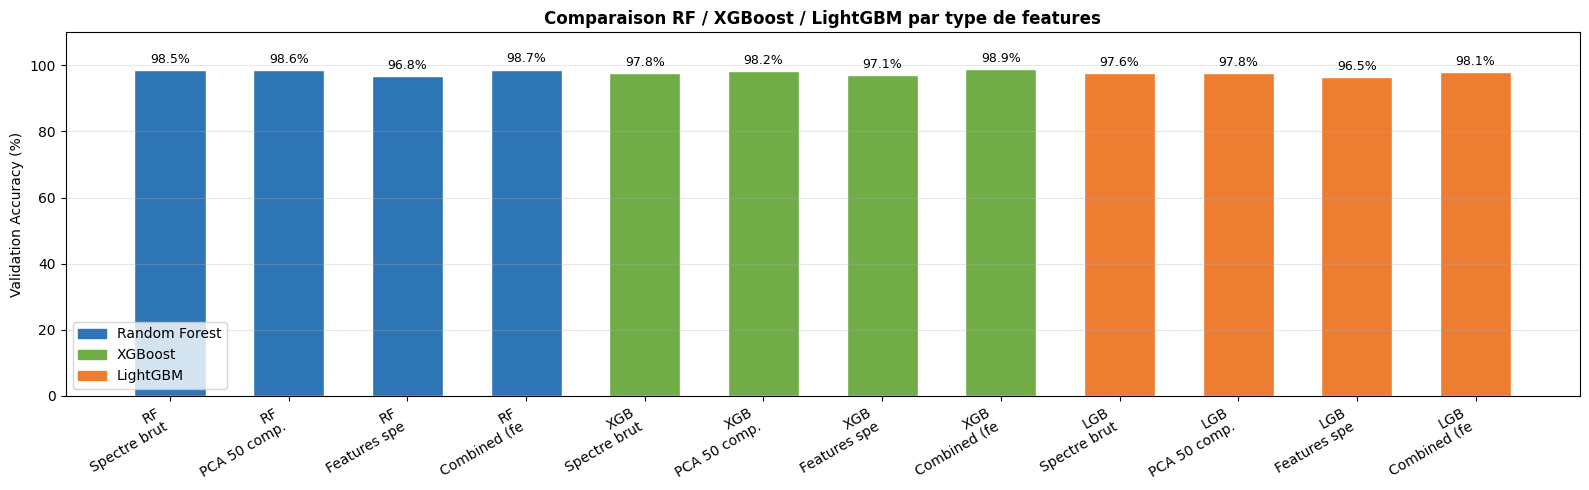

In [ ]:
# ── Graphique de comparaison ──────────────────────────────────────────────
all_models = {}
for name, res in rf_results.items():  all_models[f'RF\n{name[:12]}']  = res['acc']
for name, res in xgb_results.items(): all_models[f'XGB\n{name[:12]}'] = res['acc']
for name, res in lgb_results.items(): all_models[f'LGB\n{name[:12]}'] = res['acc']

colors = (['#2E75B6']*4 + ['#70AD47']*4 + ['#ED7D31']*4)
fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(all_models.keys(), [v*100 for v in all_models.values()],
              color=colors, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Comparaison RF / XGBoost / LightGBM par type de features', fontweight='bold')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)
# Légende manuelle
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2E75B6', label='Random Forest'),
                   Patch(color='#70AD47', label='XGBoost'),
                   Patch(color='#ED7D31', label='LightGBM')])
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Meilleur modèle global : XGB — Combined (feat+PCA)
Validation Accuracy    : 98.89%


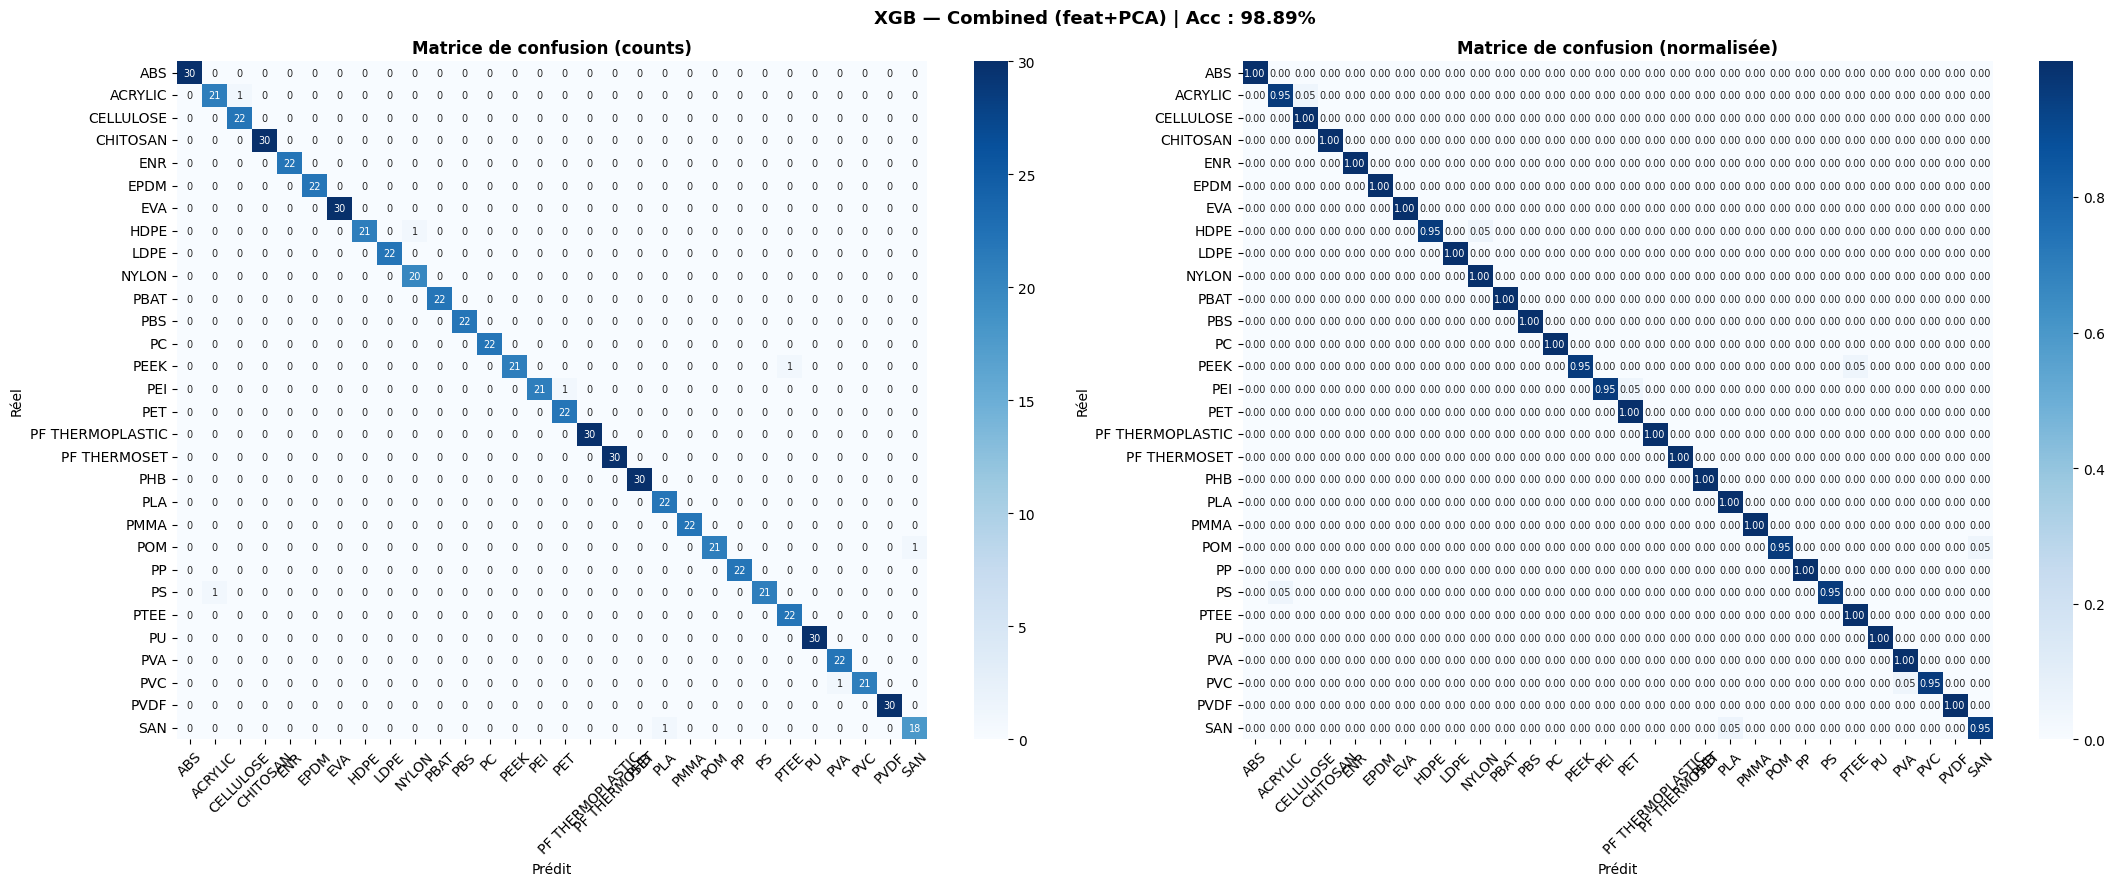

In [ ]:
# ── Matrice de confusion du meilleur modèle global ────────────────────────
# Trouver le meilleur parmi tous
all_results = {}
for k, v in rf_results.items():  all_results[('RF',  k)] = v
for k, v in xgb_results.items(): all_results[('XGB', k)] = v
for k, v in lgb_results.items(): all_results[('LGB', k)] = v

best_key = max(all_results, key=lambda k: all_results[k]['acc'])
best_res = all_results[best_key]
print(f'Meilleur modèle global : {best_key[0]} — {best_key[1]}')
print(f'Validation Accuracy    : {best_res["acc"]:.2%}')

cm      = confusion_matrix(y_val, best_res['preds'], labels=range(N_CLASSES))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Matrice de confusion (counts)', 'Matrice de confusion (normalisée)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, annot_kws={'size': 7})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'{best_key[0]} — {best_key[1]} | Acc : {best_res["acc"]:.2%}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Test sur les filtres à membrane

Les filtres à membrane sont la vraie classe inconnue.  
Un bon modèle devrait avoir une **faible confiance** sur ces échantillons.

In [ ]:
def predict_membrane(model, X_mem, le, threshold=0.35, feature_set_name='combined'):
    """
    Prédit la classe des filtres à membrane et signale l'incertitude.
    Pour RF/XGB/LGB : utilise predict_proba.
    """
    proba  = model.predict_proba(X_mem)   # (n, n_classes)
    preds  = np.argmax(proba, axis=1)
    confs  = proba.max(axis=1)

    rows = []
    for i in range(len(preds)):
        top3_idx  = np.argsort(proba[i])[::-1][:3]
        top3      = [(le.classes_[j], f'{proba[i, j]:.1%}') for j in top3_idx]
        statut    = '✅ CERTAIN' if confs[i] >= threshold else '⚠️  INCERTAIN'
        rows.append({
            'Filtre'   : f'Membrane_{i+1}',
            'Statut'   : statut,
            'Pred 1'   : top3[0][0],
            'Conf 1'   : top3[0][1],
            'Pred 2'   : top3[1][0],
            'Conf 2'   : top3[1][1],
            'Pred 3'   : top3[2][0],
            'Conf 3'   : top3[2][1],
        })
    return pd.DataFrame(rows)


# Tester le meilleur modèle de chaque famille
for label, model, Xmem in [
    ('Random Forest', best_rf,  X_mem_comb),
    ('XGBoost',       best_xgb, X_mem_comb),
    ('LightGBM',      best_lgb, X_mem_comb),
]:
    print(f'\n=== {label} — Filtres à membrane ===')
    df_mem_pred = predict_membrane(model, Xmem, le)
    print(df_mem_pred.to_string(index=False))


=== Random Forest — Filtres à membrane ===
      Filtre        Statut    Pred 1 Conf 1           Pred 2 Conf 2           Pred 3 Conf 3
  Membrane_1 ⚠️  INCERTAIN       PVC  31.8%        CELLULOSE  15.0%              PVA   8.8%
  Membrane_2 ⚠️  INCERTAIN       PVC  29.4%        CELLULOSE  27.2%             LDPE   9.0%
  Membrane_3 ⚠️  INCERTAIN       PVC  30.6%        CELLULOSE  19.0%              PET   5.6%
  Membrane_4 ⚠️  INCERTAIN       PVC  30.2%        CELLULOSE  20.8%             LDPE   6.6%
  Membrane_5 ⚠️  INCERTAIN       PVC  25.2%        CELLULOSE  16.0%              PVA   7.2%
  Membrane_6 ⚠️  INCERTAIN       PVC  27.8%        CELLULOSE  14.6%              PVA   9.6%
  Membrane_7 ⚠️  INCERTAIN       PVC  17.6%        CELLULOSE  15.0%             LDPE   8.8%
  Membrane_8 ⚠️  INCERTAIN CELLULOSE  16.6%               PP  13.8%              PVC  13.4%
  Membrane_9 ⚠️  INCERTAIN       PVC  22.4%        CELLULOSE  14.8%              PVA   9.4%
 Membrane_10 ⚠️  INCERTAIN       PVC

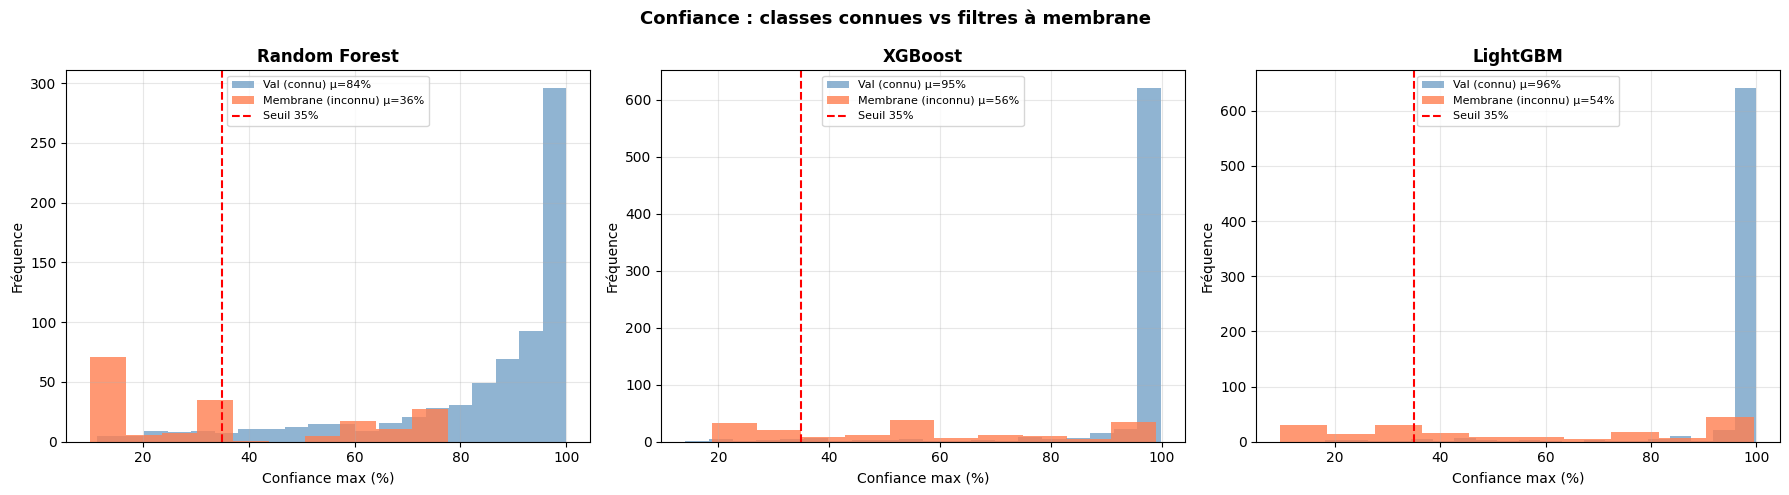

In [ ]:
# ── Visualisation : distribution des confidences ──────────────────────────
# Comparer val set (connu) vs filtres (inconnu) pour chaque modèle

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, model, Xmem, Xval_set) in zip(axes, [
    ('Random Forest', best_rf,  X_mem_comb, X_val),
    ('XGBoost',       best_xgb, X_mem_comb, X_val),
    ('LightGBM',      best_lgb, X_mem_comb, X_val),
]):
    conf_val = model.predict_proba(Xval_set).max(axis=1)
    conf_mem = model.predict_proba(Xmem).max(axis=1)

    ax.hist(conf_val * 100, bins=20, alpha=0.6, color='steelblue',
            label=f'Val (connu) μ={conf_val.mean():.0%}')
    ax.hist(conf_mem * 100, bins=10, alpha=0.8, color='coral',
            label=f'Membrane (inconnu) μ={conf_mem.mean():.0%}')
    ax.axvline(35, color='red', linestyle='--', linewidth=1.5, label='Seuil 35%')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Confiance max (%)')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Confiance : classes connues vs filtres à membrane',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Récapitulatif — ML classique vs PatchTST

In [ ]:
# ── Tableau de synthèse final ─────────────────────────────────────────────
# ⚠️  Remplace les valeurs PatchTST par tes vrais résultats

PATCHTST_VAL_ACC = 0.80   # ← ton résultat réel
PATCHTST_VAL_F1  = None   # ← ton résultat réel (si disponible)

# Meilleurs de chaque famille
best_rf_acc  = max(v['acc'] for v in rf_results.values())
best_rf_f1   = max(v['f1'] for v in rf_results.values())
best_xgb_acc = max(v['acc'] for v in xgb_results.values())
best_xgb_f1  = max(v['f1'] for v in xgb_results.values())
best_lgb_acc = max(v['acc'] for v in lgb_results.values())
best_lgb_f1  = max(v['f1'] for v in lgb_results.values())

recap = pd.DataFrame([
    {'Modèle': 'Random Forest (best)',  'Val Acc': f'{best_rf_acc:.2%}',
     'Val F1 macro': f'{best_rf_f1:.3f}',
     'Params': '500 arbres', 'Entraînement': '< 1 min',
     'Interprétabilité': '⭐⭐⭐'},
    {'Modèle': 'XGBoost (best)',        'Val Acc': f'{best_xgb_acc:.2%}',
     'Val F1 macro': f'{best_xgb_f1:.3f}',
     'Params': '500 trees', 'Entraînement': '1-3 min',
     'Interprétabilité': '⭐⭐'},
    {'Modèle': 'LightGBM (best)',       'Val Acc': f'{best_lgb_acc:.2%}',
     'Val F1 macro': f'{best_lgb_f1:.3f}',
     'Params': '500 trees', 'Entraînement': '< 1 min',
     'Interprétabilité': '⭐⭐'},
    {'Modèle': 'PatchTST (notebook 1)', 'Val Acc': f'{PATCHTST_VAL_ACC:.2%}',
     'Val F1 macro': str(PATCHTST_VAL_F1),
     'Params': '117k', 'Entraînement': '~10 min',
     'Interprétabilité': '⭐'},
])

print('=== RÉCAPITULATIF FINAL ===')
print(recap.to_string(index=False))

# ── Graphique ─────────────────────────────────────────────────────────────
models_names = ['Random\nForest', 'XGBoost', 'LightGBM', 'PatchTST']
accs         = [best_rf_acc, best_xgb_acc, best_lgb_acc, PATCHTST_VAL_ACC]
colors_bar   = ['#2E75B6', '#70AD47', '#ED7D31', '#7030A0']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(models_names, [a*100 for a in accs],
              color=colors_bar, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('ML Classique vs Deep Learning\nClassification FTIR Microplastiques',
             fontweight='bold', fontsize=13)
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✓ Graphique sauvegardé : comparison_models.png')

## Notes d'interprétation

### Quand RF/GB surpassent PatchTST
- Dataset petit (< 500 spectres) : les arbres généralisent mieux avec peu de données
- Features spectrales bien construites : le prior chimique (bandes FTIR) compense le manque de données
- Entraînement plus rapide et reproductible : utile pour itérer

### Quand PatchTST surpasse RF/GB
- Dataset plus grand (> 1000 spectres)
- Spectres bruités : PatchTST apprend à ignorer le bruit via l'attention
- Transfer learning : pré-entraînement sur données non-étiquetées impossible avec RF/GB

### Pour ton rapport
- Présente RF/GB comme **baseline solide et interprétable**
- L'importance des features RF te dit **quelles bandes FTIR** sont discriminantes
- PatchTST est la direction pour scaler avec plus de données
